<img src="https://storage.googleapis.com/kaggle-datasets-images/4749485/8053271/ead2524e9a9ed5d65d920e5f9d807d15/dataset-cover.png?t=2024-04-07-11-33-07" width="400" align="center"></a>

<h1 align="center"><font size="5">Project: Indian Rental House Price - Predict "Price"</font></h1>
<h2 align="center"><font size="5">Deadline: 2024-07-14 00:00:00 (Monday)</font></h2>
<h3 align="center"><font size="5"> Total marks: 4.0</font></h3>

### Chú ý: Học viên tạo folder trên Google Drive theo cú pháp: DL04_HoVaTen_Thi, upload toàn bộ bài thi lên >> Share folder này cho thầy theo email: datafarmer2019@gmail.com để thầy chấm điểm. Yêu cầu: Nộp bài đúng deadline. Bài làm giống nhau bị trừ điểm.

### Your information:
- Fullname:
- Date of birth:
- Place of birth:
- Email:
- Mobile phone:

In this notebook, we practice all the knowledge and skills that we have learned in this course (DL04: Data pre-processing and Analysis)

We apply the **Linear Regression Algorithm** to predict: **"Price"** by accuracy evaluation methods.

<!-- Please read [Gemstone price prediction information](https://www.kaggle.com/datasets/colearninglounge/gemstone-price-prediction) carefully before you do this project! -->

Dataset: Indian_housing_Delhi_data.csv

#### Data dictionary:


* House Type: Type of house (e.g., apartment, villa, duplex).
* House Size: Size of the house in square feet or square meters.
* Location: Specific area or neighborhood where the property is located.
* City: City in India where the property is situated.
* Latitude: Geographic latitude coordinates of the property location.
* Longitude: Geographic longitude coordinates of the property location.
* Price: Rental price of the house.
* Currency: Currency in which the price is denoted (e.g., INR - Indian Rupees).
* Number of Bathrooms: Total number of bathrooms in the house.
* Number of Balconies: Total number of balconies in the house.
* Negotiability: Indicates whether the price is negotiable (Yes/No).
* Price per Square Foot: Price of the house per square foot.
* Verification Date: Date when the rental information was verified.
* Description: Additional description or details about the property.
* Security Deposit: Amount of security deposit required for renting the property.
* Status: Indicates the furnishing status of the property (furnished, unfurnished, semi-furnished).



### Requirements:

- Data exploration
- Data visualization
- Pre-processing: Feature selection/extraction
- Linear Regression
    - Model Evaluation using Test set
    - Report

## Import library package

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.analyzer import TTTH_Analyzer
from processor.feature import FeatureProcessor

In [2]:
_analyzer = TTTH_Analyzer()
_processor = FeatureProcessor()

## Read dataset and check overview

,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status
0,1 RK Studio Apartment,400 sq ft,Kalkaji,Delhi,28.545561,77.254349,22000,INR,1.0,NaN,NaN,NaN,Posted a day ago,"Fully furnished, loaded with amenities & gadge...",No Deposit,Furnished
1,1 RK Studio Apartment,400 sq ft,Mansarover Garden,Delhi,28.643259,77.132828,20000,INR,1.0,NaN,NaN,NaN,Posted 9 days ago,Here is an excellent 1 BHK Independent Floor a...,No Deposit,Furnished
2,2 BHK Independent Floor,500 sq ft,Uttam Nagar,Delhi,28.618677,77.053352,8500,INR,1.0,NaN,NaN,NaN,Posted 12 days ago,"Zero Brokerage.\n\n2 Room set, Govt bijali Met...",No Deposit,Semi-Furnished
3,3 BHK Independent House,"1,020 sq ft",Model Town,Delhi,28.712898,77.180000,48000,INR,3.0,NaN,NaN,NaN,Posted a year ago,Itâs a 3 bhk independent house situated in M...,No Deposit,Furnished
4,2 BHK Apartment,810 sq ft,Sector 13 Rohini,Delhi,28.723539,77.131424,20000,INR,2.0,NaN,NaN,NaN,Posted a year ago,Well designed 2 bhk multistorey apartment is a...,No Deposit,Unfurnished


,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status
4995,4 BHK Villa,"5,896 sq ft",Sunder Nagar,Delhi,28.618437,76.961784,1022001,INR,4.0,2.0,NaN,NaN,Posted 2 months ago,Its four bhk villa in the super location of De...,"40,10,102",Unfurnished
4996,5 BHK Independent House,"6,521 sq ft",Sunder Nagar,Delhi,28.618437,76.961784,1549181,INR,4.0,2.0,NaN,NaN,Posted 2 months ago,A 5 bhk property is available for rent in Sund...,"54,01,015",Unfurnished
4997,3 BHK Independent Floor,"1,855 sq ft",New Friends Colony,Delhi,28.567051,77.273560,301012,INR,3.0,2.0,NaN,NaN,Posted 2 months ago,Its three bhk builder floor in the super locat...,"18,18,181",Unfurnished
4998,3 BHK Independent Floor,"2,856 sq ft",New Friends Colony,Delhi,28.567051,77.273560,301011,INR,3.0,2.0,NaN,NaN,Posted 2 months ago,Its three bhk builder floor in the super locat...,"10,10,110",Unfurnished
4999,3 BHK Independent Floor,"2,856 sq ft",New Friends Colony,Delhi,28.567051,77.273560,301012,INR,4.0,2.0,NaN,NaN,Posted 2 months ago,Its three bhk builder floor in the super locat...,"10,10,182",Unfurnished


,latitude,longitude,price,numBathrooms,numBalconies,priceSqFt
count,5000.000000,5000.000000,5.000000e+03,4975.000000,2737.000000,0.0
mean,28.578012,77.174499,2.221738e+05,2.918593,1.954330,NaN
std,0.190186,0.115636,2.739843e+05,1.087823,0.547219,NaN
min,20.011379,72.771332,3.000000e+03,1.000000,1.000000,NaN
25%,28.544489,77.138248,2.950000e+04,2.000000,2.000000,NaN
50%,28.569295,77.196472,1.250000e+05,3.000000,2.000000,NaN
75%,28.618687,77.228950,3.011020e+05,4.000000,2.000000,NaN
max,28.805466,80.361313,3.010101e+06,10.000000,8.000000,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   house_type        5000 non-null   object 
 1   house_size        5000 non-null   object 
 2   location          5000 non-null   object 
 3   city              5000 non-null   object 
 4   latitude          5000 non-null   float64
 5   longitude         5000 non-null   float64
 6   price             5000 non-null   int64  
 7   currency          5000 non-null   object 
 8   numBathrooms      4975 non-null   float64
 9   numBalconies      2737 non-null   float64
 10  isNegotiable      179 non-null    object 
 11  priceSqFt         0 non-null      float64
 12  verificationDate  5000 non-null   object 
 13  description       4715 non-null   object 
 14  SecurityDeposit   5000 non-null   object 
 15  Status            5000 non-null   object 
dtypes: float64(5), int64(1), object(10)
memory

* priceSqFt, numBalconies, isNegotiable missing many value, need to drop it 
* house_size need preprocessing 
* numBathrooms have missing value, need to handle 
* description is text, consider to preprocessing or drop it
* latitude, longitude is coordinate, not use for predict price, drop it
* Verification Date need to be preprocessing

## Drop un-use variables

In [8]:
# drop 'priceSqFt', 'numBalconies', 'isNegotiable', 'description', 'latitude', 'longitude', 'description'

In [9]:
# Should we drop currency?

array(['INR'], dtype=object)

* Seem that currency is only have 1 values, can be drop

## Remove duplicates

In [11]:
# Do we have duplicated data?

True

* There is duplicated value, need to de-duplicate

(4358, 9)

## Handle missing value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4358 entries, 0 to 4357
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   house_type        4358 non-null   object 
 1   house_size        4358 non-null   object 
 2   location          4358 non-null   object 
 3   city              4358 non-null   object 
 4   price             4358 non-null   int64  
 5   numBathrooms      4333 non-null   float64
 6   verificationDate  4358 non-null   object 
 7   SecurityDeposit   4358 non-null   object 
 8   Status            4358 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 306.5+ KB


numBathrooms before fill missing values: 25
numBathrooms after fill missing values: 0


## Identify variable

Index(['house_type', 'house_size', 'location', 'city', 'price', 'numBathrooms',
       'verificationDate', 'SecurityDeposit', 'Status'],
      dtype='object')

As requirement, predict `price` so
* Output variable: price
* Input variable: 
    * house_type -> category
    * house_size -> numeric (preprocess)
    * location -> category
    * city -> category
    * numBathrooms -> numeric
    * verificationDate -> category (preprocess)
    * SecurityDeposit -> numeric
    * Status -> category

In [17]:
# Preprocessing house_size and convert it to numeric


In [18]:
# Preprocessing verificationDate and convert it to category


,house_type,house_size,location,city,price,numBathrooms,verificationDate,SecurityDeposit,Status
0,1 RK Studio Apartment,400,Kalkaji,Delhi,22000,1.0,a day,No Deposit,Furnished
1,1 RK Studio Apartment,400,Mansarover Garden,Delhi,20000,1.0,9 days,No Deposit,Furnished
2,2 BHK Independent Floor,500,Uttam Nagar,Delhi,8500,1.0,12 days,No Deposit,Semi-Furnished
3,3 BHK Independent House,1020,Model Town,Delhi,48000,3.0,a year,No Deposit,Furnished
4,2 BHK Apartment,810,Sector 13 Rohini,Delhi,20000,2.0,a year,No Deposit,Unfurnished


### Split into numeric and category dataframe to analyze

In [21]:
# Now we should have output, input_numeric, input_category dataframe

,house_type,location,city,verificationDate,SecurityDeposit,Status
0,1 RK Studio Apartment,Kalkaji,Delhi,a day,No Deposit,Furnished
1,1 RK Studio Apartment,Mansarover Garden,Delhi,9 days,No Deposit,Furnished
2,2 BHK Independent Floor,Uttam Nagar,Delhi,12 days,No Deposit,Semi-Furnished
3,3 BHK Independent House,Model Town,Delhi,a year,No Deposit,Furnished
4,2 BHK Apartment,Sector 13 Rohini,Delhi,a year,No Deposit,Unfurnished


,house_size,numBathrooms
0,400,1.0
1,400,1.0
2,500,1.0
3,1020,3.0
4,810,2.0


## Univariate analysis

### Input Category analysis

Index(['house_type', 'location', 'city', 'verificationDate', 'SecurityDeposit',
       'Status'],
      dtype='object')

Class count of house_type:

3 BHK Independent Floor      1315
4 BHK Independent Floor       697
2 BHK Independent Floor       467
3 BHK Apartment               289
4 BHK Villa                   236
2 BHK Apartment               203
1 BHK Independent Floor       198
1 BHK Apartment               167
5 BHK Independent Floor       155
5 BHK Villa                   145
5 BHK Independent House       111
4 BHK Independent House       107
1 RK Studio Apartment         105
4 BHK Apartment                99
3 BHK Independent House        18
2 BHK Independent House        17
1 BHK Independent House         6
6 BHK Independent Floor         5
5 BHK Apartment                 5
9 BHK Independent House         3
7 BHK Independent Floor         2
10 BHK Independent House        2
8 BHK Independent Floor         1
8 BHK Independent House         1
7 BHK Independent House         1
8 BHK Villa                     1
6 BHK penthouse                 1
12 BHK Independent House        1
Name: house_type, dt

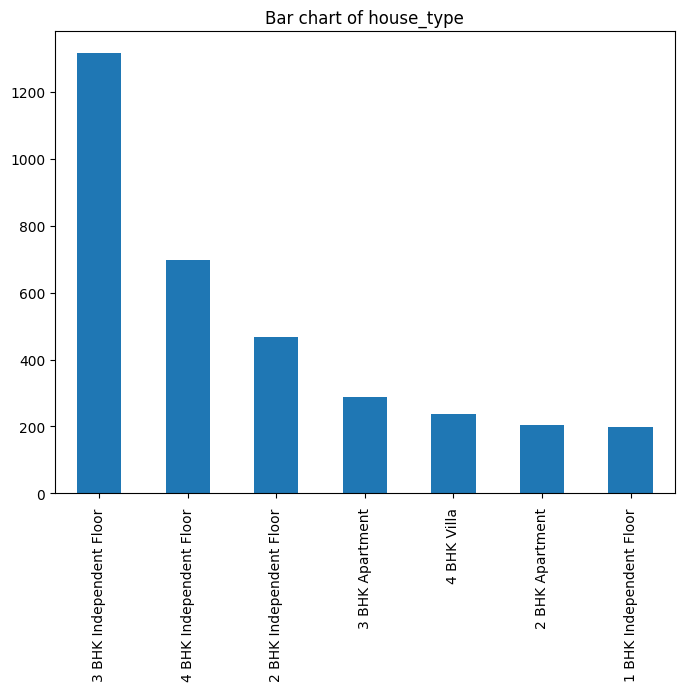

What is top house type?

Class count of location:

Defence Colony            158
Greater kailash 1         136
Chattarpur                124
Jor bagh                  112
Vasant Vihar              111
                         ... 
Sector 17 Dwarka            1
Kamla Nagar                 1
Sector 6 Rohini             1
B1 Block Paschim Vihar      1
dda flat                    1
Name: location, Length: 288, dtype: int64


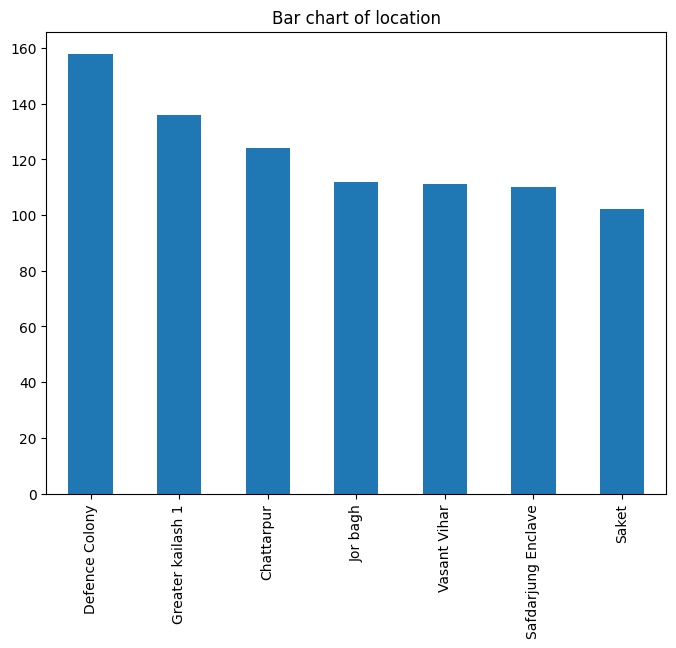

What is top location? Do we need to pre-processing anything else?

Class count of city:

Delhi    4358
Name: city, dtype: int64


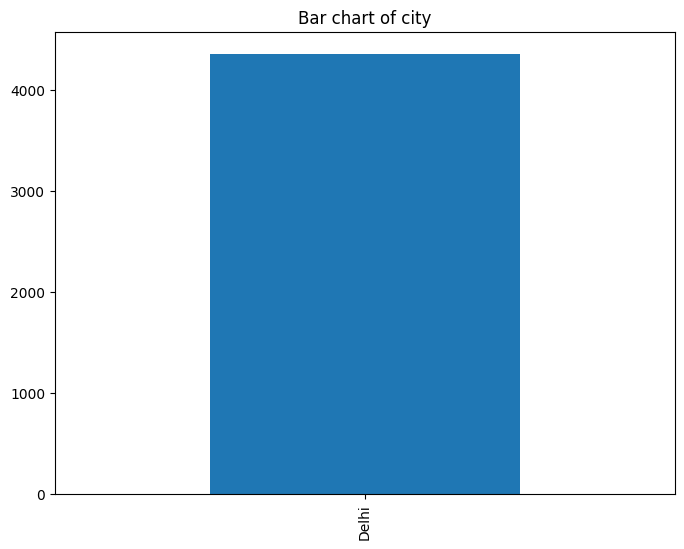

Can we use city for predict price?

Class count of verificationDate:

a year        1022
5 months       509
3 years        434
2 months       412
6 months       406
a month        323
16 days        270
2 years        102
15 days         87
10 days         63
9 days          57
11 days         57
3 days          46
6 days          46
2 days          42
20 days         41
23 days         39
7 days          37
4 years         36
5 days          34
19 days         34
12 days         32
3 months        30
22 days         24
25 days         22
a day           22
4 days          18
17 days         16
18 days         14
24 days         12
8 days          11
13 days          9
14 days          7
21 days          7
9 months         6
21 hours         4
4 months         3
9 hours          3
14 hours         3
13 hours         3
an hour          2
37 minutes       2
6 hours          2
19 hours         1
10 months        1
17 hours         1
16 hours         1
5 hours          1
4 hours          1
2 hours          1
35 minutes      

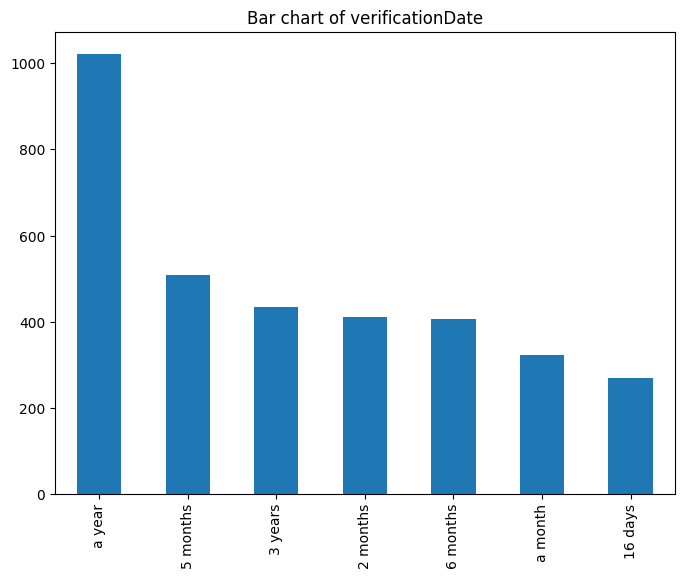

What is top of verificationDate? Do we need to pre-processing anything else?

Class count of SecurityDeposit:

No Deposit    1926
 10,10,202     188
 10,20,202      66
 18,10,202      61
 10,10,220      56
              ... 
 12,02,012       1
 25,41,818       1
 11,81,101       1
 11,01,010       1
 54,01,015       1
Name: SecurityDeposit, Length: 646, dtype: int64


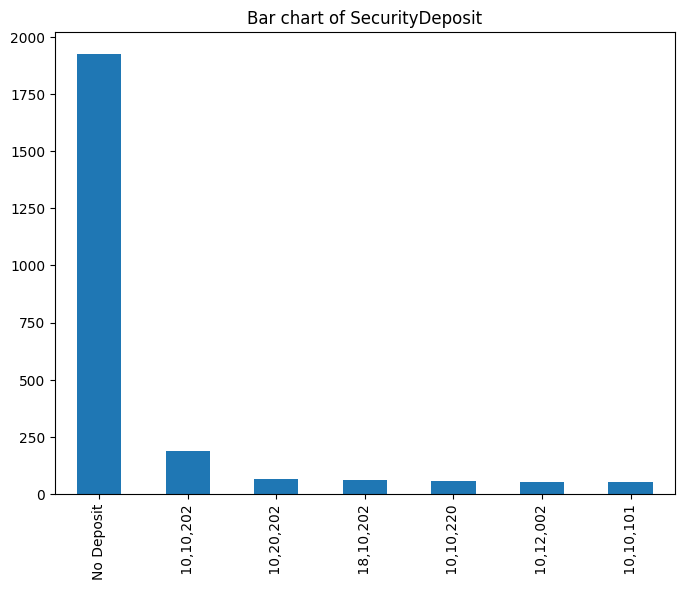

Can we do somthing with SecurityDeposit?

Class count of Status:

Unfurnished       2029
Semi-Furnished    1686
Furnished          643
Name: Status, dtype: int64


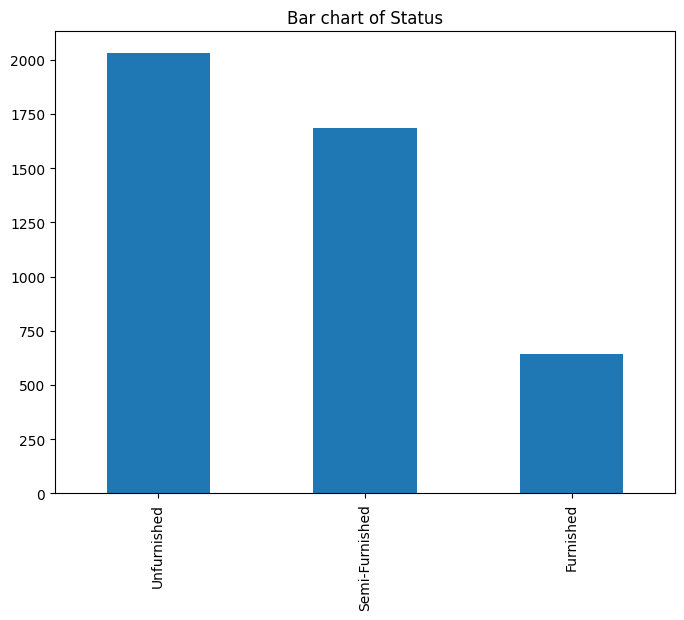

What is top of Status?

### Preprocessing

,house_type,location,verificationDate,Status
0,1 RK Studio Apartment,Kalkaji,a day,Furnished
1,1 RK Studio Apartment,Mansarover Garden,9 days,Furnished
2,2 BHK Independent Floor,Uttam Nagar,12 days,Semi-Furnished
3,3 BHK Independent House,Model Town,a year,Furnished
4,2 BHK Apartment,Sector 13 Rohini,a year,Unfurnished


,house_size,numBathrooms,SecurityDeposit
0,400,1.0,0
1,400,1.0,0
2,500,1.0,0
3,1020,3.0,0
4,810,2.0,0


### Input Numerical analysis

Index(['house_size', 'numBathrooms', 'SecurityDeposit'], dtype='object')

=====
central tendency of house_size: {'mean': 2980.651675080312, 'median': 2500.0, 'mode': 5896, 'min': 150, 'max': 14521, 'range': 14371}
=====
Dispersion of house_size: 
 {'range': 14371, 'q1': 1050.0, 'q3': 5891.0, 'iqr': 4841.0, 'var': 4707389.041827582, 'skew': 0.5968938000394077, 'kurtosis': -0.9571725278673608}
=====


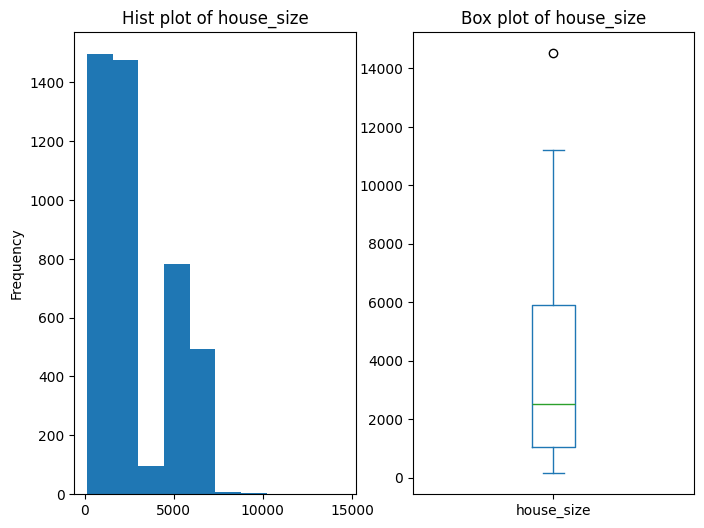

`house_size` have upper outlier, skew right

=====
central tendency of numBathrooms: {'mean': 2.9132629646626893, 'median': 3.0, 'mode': 4.0, 'min': 1.0, 'max': 10.0, 'range': 9.0}
=====
Dispersion of numBathrooms: 
 {'range': 9.0, 'q1': 2.0, 'q3': 4.0, 'iqr': 2.0, 'var': 1.1813663990457874, 'skew': -0.0593339862885595, 'kurtosis': 0.6038183159957526}
=====


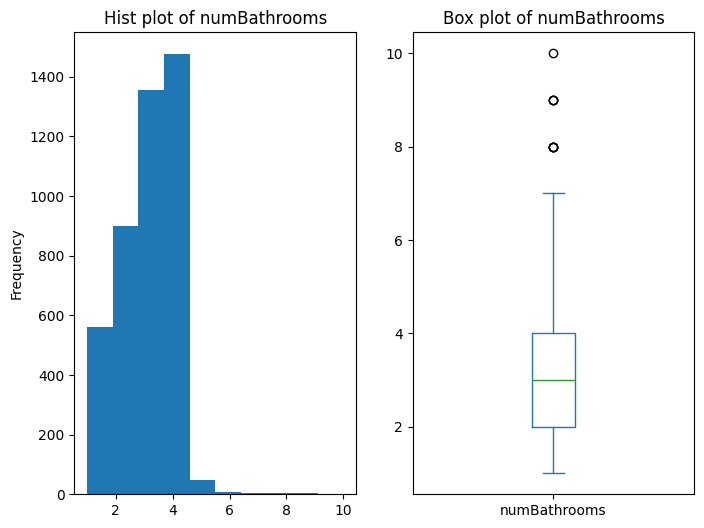

`numBathrooms` have right skew, have upper outlier

=====
central tendency of SecurityDeposit: {'mean': 640785.0100963744, 'median': 36000.0, 'mode': 0, 'min': 0, 'max': 11401010, 'range': 11401010}
=====
Dispersion of SecurityDeposit: 
 {'range': 11401010, 'q1': 0.0, 'q3': 1012002.0, 'iqr': 1012002.0, 'var': 941866409926.25, 'skew': 2.5317494444482156, 'kurtosis': 10.524419426023552}
=====


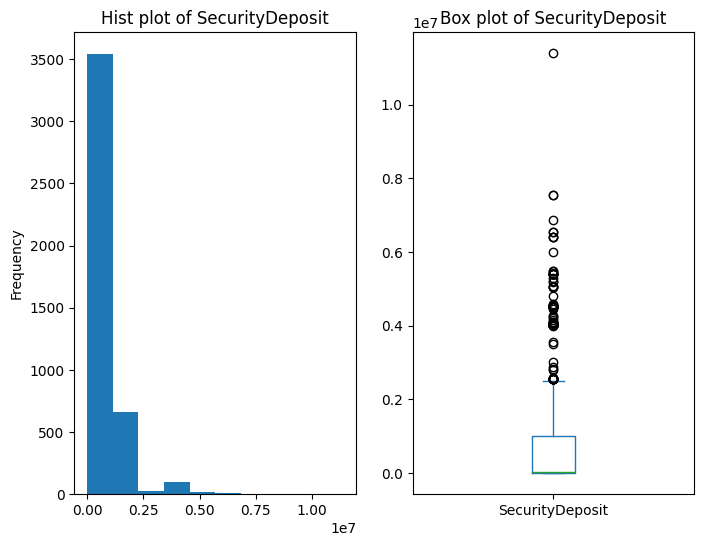

`SecurityDeposit` have many upper outlier, right skew

### Output Numerical analysis

=====
central tendency of price: {'mean': 218557.1727856815, 'median': 125000.0, 'mode': 301012, 'min': 3000, 'max': 3010101, 'range': 3007101}
=====
Dispersion of price: 
 {'range': 3007101, 'q1': 28000.0, 'q3': 301102.0, 'iqr': 273102.0, 'var': 72841174912.72823, 'skew': 2.9627465675445785, 'kurtosis': 13.874571336493755}
=====


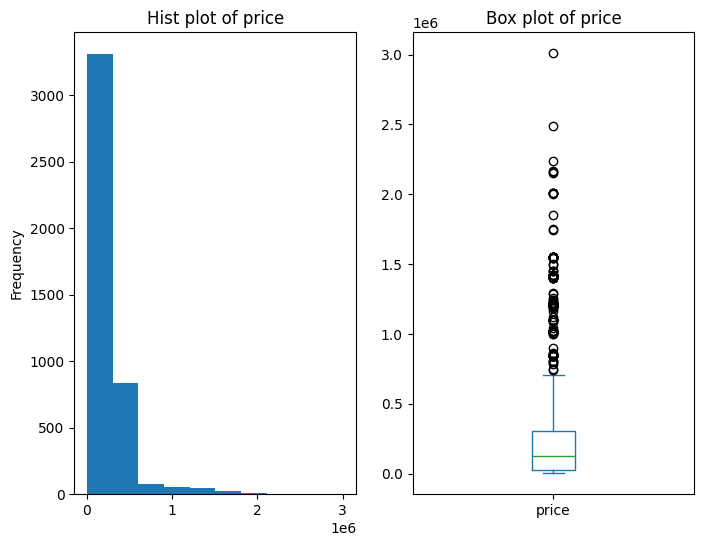

`price` have many upper outlier, right skew

## Bi-variate analysis

### Handle uncommon category

Before group uncommon category to Rare 
: 3 BHK Independent Floor      1315
4 BHK Independent Floor       697
2 BHK Independent Floor       467
3 BHK Apartment               289
4 BHK Villa                   236
2 BHK Apartment               203
1 BHK Independent Floor       198
1 BHK Apartment               167
5 BHK Independent Floor       155
5 BHK Villa                   145
5 BHK Independent House       111
4 BHK Independent House       107
1 RK Studio Apartment         105
4 BHK Apartment                99
3 BHK Independent House        18
2 BHK Independent House        17
1 BHK Independent House         6
6 BHK Independent Floor         5
5 BHK Apartment                 5
9 BHK Independent House         3
7 BHK Independent Floor         2
10 BHK Independent House        2
8 BHK Independent Floor         1
8 BHK Independent House         1
7 BHK Independent House         1
8 BHK Villa                     1
6 BHK penthouse                 1
12 BHK Independent House        1
Name: 

Before group uncommon category to Rare 
: Defence Colony            158
Greater kailash 1         136
Chattarpur                124
Jor bagh                  112
Vasant Vihar              111
                         ... 
Sector 17 Dwarka            1
Kamla Nagar                 1
Sector 6 Rohini             1
B1 Block Paschim Vihar      1
dda flat                    1
Name: location, Length: 288, dtype: int64
After group uncommon category to Rare 
: Rare                 298
Defence Colony       158
Greater kailash 1    136
Chattarpur           124
Jor bagh             112
                    ... 
laxmi nagar            6
Sector-7 Rohini        5
Connaught Place        5
Punjabi Bagh           5
Manglapuri             5
Name: location, Length: 113, dtype: int64


Before group uncommon category to Rare 
: a year        1022
5 months       509
3 years        434
2 months       412
6 months       406
a month        323
16 days        270
2 years        102
15 days         87
10 days         63
9 days          57
11 days         57
3 days          46
6 days          46
2 days          42
20 days         41
23 days         39
7 days          37
4 years         36
5 days          34
19 days         34
12 days         32
3 months        30
22 days         24
25 days         22
a day           22
4 days          18
17 days         16
18 days         14
24 days         12
8 days          11
13 days          9
14 days          7
21 days          7
9 months         6
21 hours         4
4 months         3
9 hours          3
14 hours         3
13 hours         3
an hour          2
37 minutes       2
6 hours          2
19 hours         1
10 months        1
17 hours         1
16 hours         1
5 hours          1
4 hours          1
2 hours          1
35 minut

### Continuous vs Continuous (Input and Output)

,house_size,numBathrooms,SecurityDeposit,price
house_size,1.000000,0.837344,0.696463,0.734709
numBathrooms,0.837344,1.000000,0.510451,0.602290
SecurityDeposit,0.696463,0.510451,1.000000,0.921409
price,0.734709,0.602290,0.921409,1.000000


`house_size`, `SecurityDeposit`, `numBathrooms` have correlation with `price`

### Input Category vs Input Category 

[{'house_type', 'location'},
 {'house_type', 'verificationDate'},
 {'Status', 'house_type'},
 {'location', 'verificationDate'},
 {'Status', 'location'},
 {'Status', 'verificationDate'}]

=====Analyze of location and house_type=====


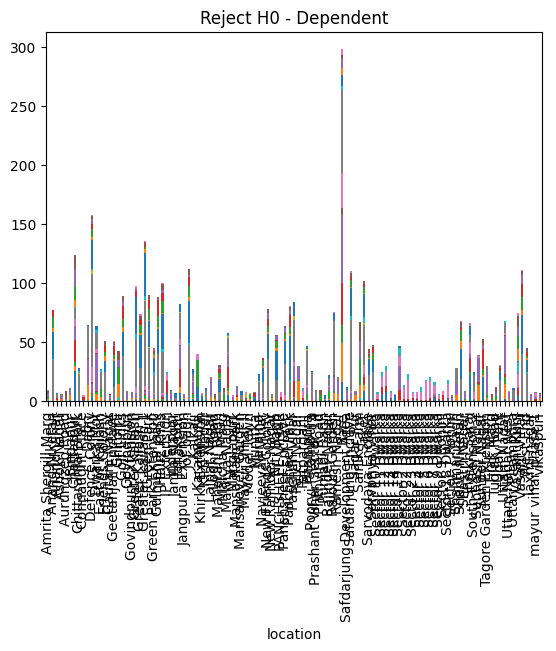

=====Analyze of house_type and verificationDate=====


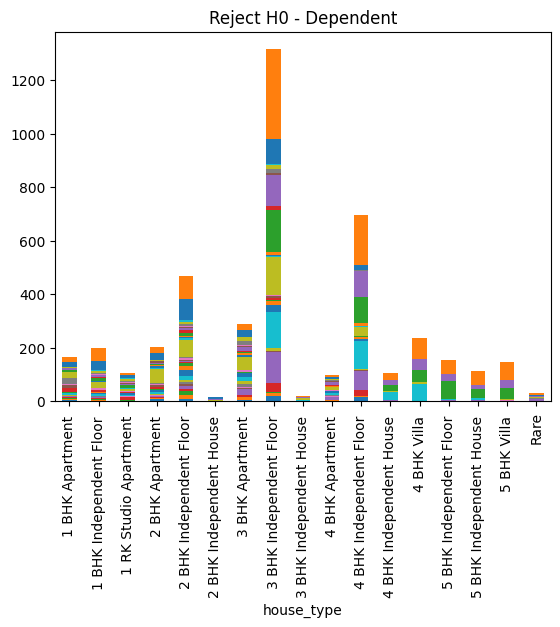

=====Analyze of Status and house_type=====


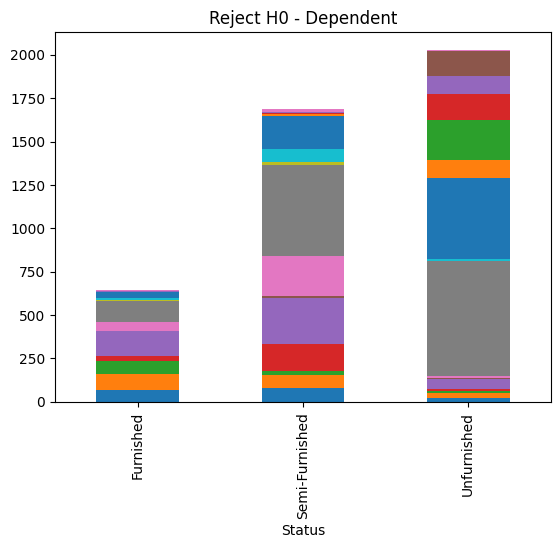

=====Analyze of location and verificationDate=====


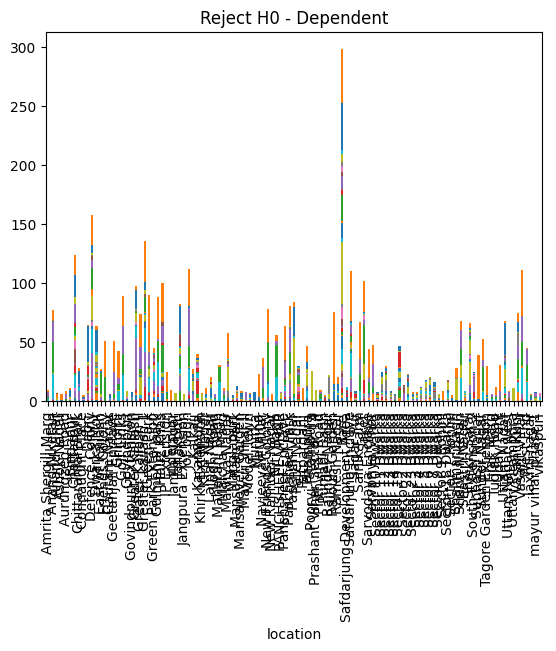

=====Analyze of Status and location=====


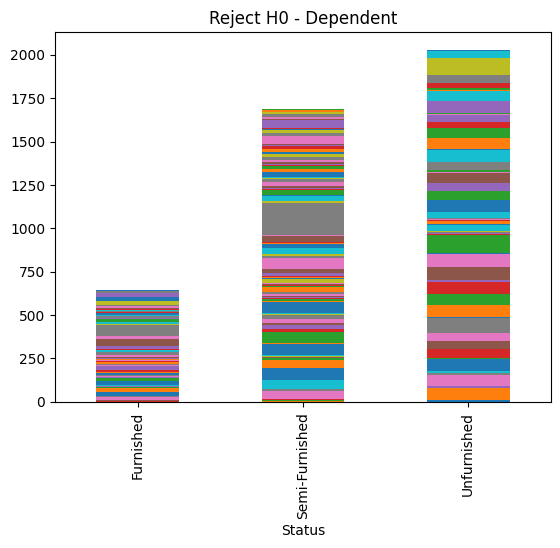

=====Analyze of Status and verificationDate=====


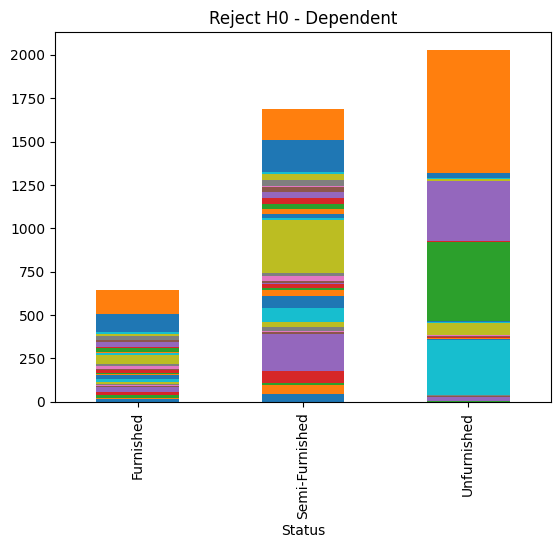

,var1,var2,result
0,location,house_type,Reject H0 - Dependent
1,house_type,verificationDate,Reject H0 - Dependent
2,Status,house_type,Reject H0 - Dependent
3,location,verificationDate,Reject H0 - Dependent
4,Status,location,Reject H0 - Dependent
5,Status,verificationDate,Reject H0 - Dependent


* Seem that all category variable have relation with others

### Output Continuous vs Input Category 

Index(['house_type', 'location', 'verificationDate', 'Status'], dtype='object')

                     sum_sq      df           F  PR(>F)
C(house_type)  1.756874e+14    16.0  336.431814     0.0
Residual       1.416816e+14  4341.0         NaN     NaN


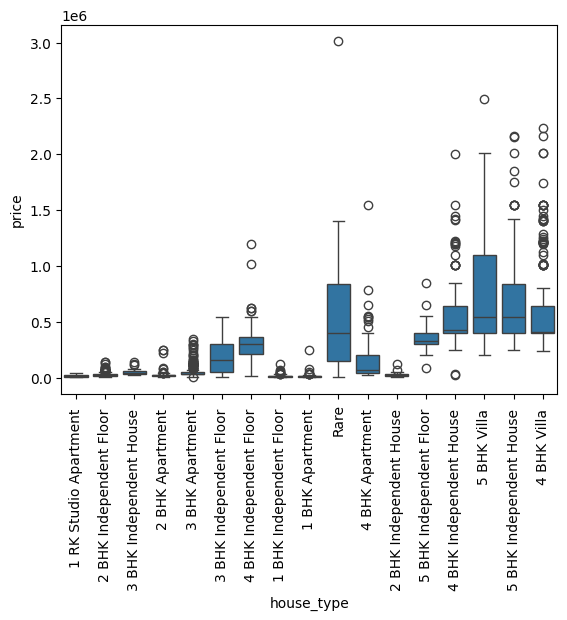

                   sum_sq      df          F  PR(>F)
C(location)  1.965878e+14   112.0  61.690315     0.0
Residual     1.207812e+14  4245.0        NaN     NaN


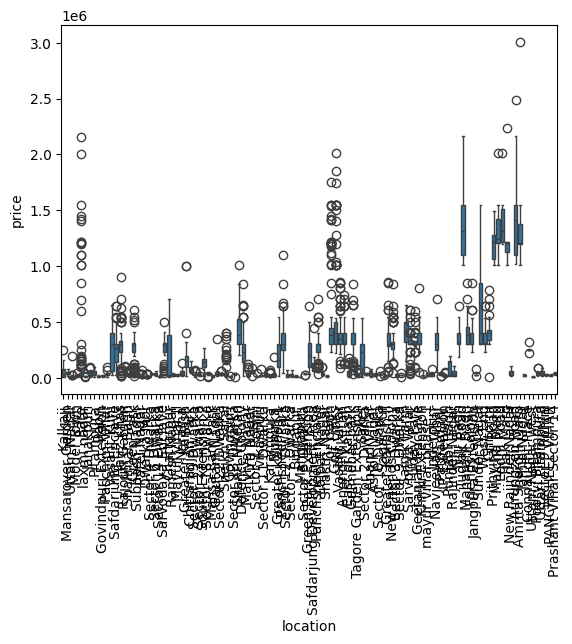

                           sum_sq      df          F         PR(>F)
C(verificationDate)  8.391839e+13    31.0  50.163402  1.021348e-260
Residual             2.334506e+14  4326.0        NaN            NaN


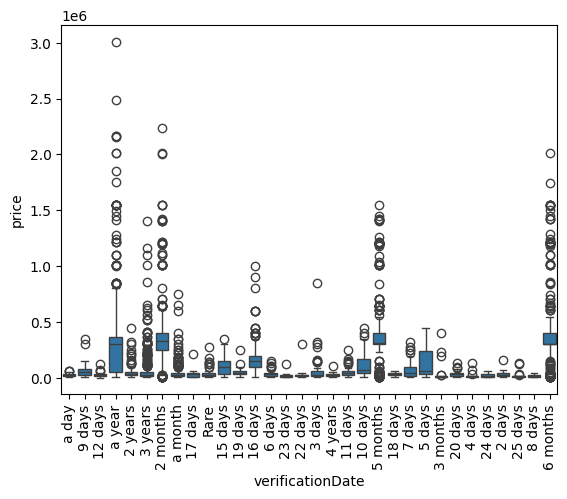

                 sum_sq      df            F  PR(>F)
C(Status)  1.111686e+14     2.0  1173.953033     0.0
Residual   2.062004e+14  4355.0          NaN     NaN


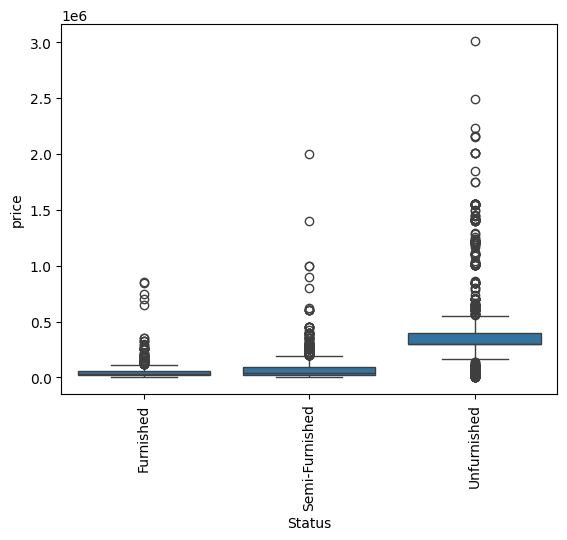

* Most of input category have no relation with output numeric, only `verificationDate` have relation

### Input Category vs Input Continuous 

['house_size', 'numBathrooms', 'SecurityDeposit']

['house_type', 'location', 'verificationDate', 'Status']

,house_size,numBathrooms,SecurityDeposit,house_type,location,verificationDate,Status
0,400,1.0,0,1 RK Studio Apartment,Kalkaji,a day,Furnished
1,400,1.0,0,1 RK Studio Apartment,Mansarover Garden,9 days,Furnished
2,500,1.0,0,2 BHK Independent Floor,Uttam Nagar,12 days,Semi-Furnished
3,1020,3.0,0,3 BHK Independent House,Model Town,a year,Furnished
4,810,2.0,0,2 BHK Apartment,Rare,a year,Unfurnished


                     sum_sq      df            F  PR(>F)
C(house_type)  1.740204e+10    16.0  1519.083772     0.0
Residual       3.108052e+09  4341.0          NaN     NaN


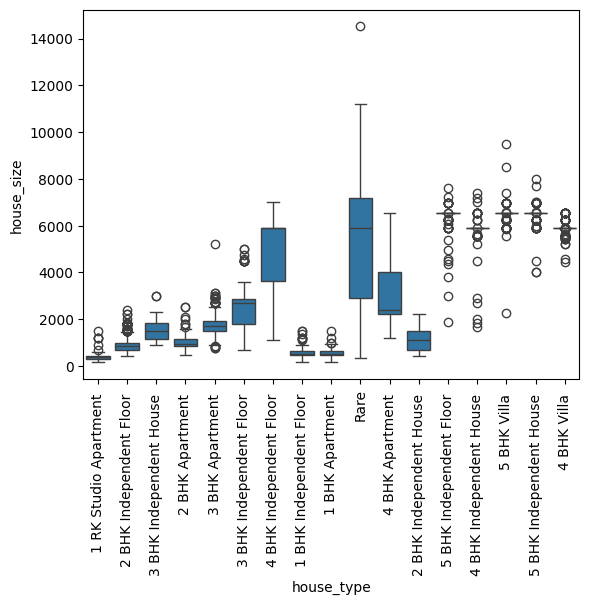

                    sum_sq      df            F  PR(>F)
C(house_type)  4301.665171    16.0  1380.282628     0.0
Residual        845.548229  4341.0          NaN     NaN


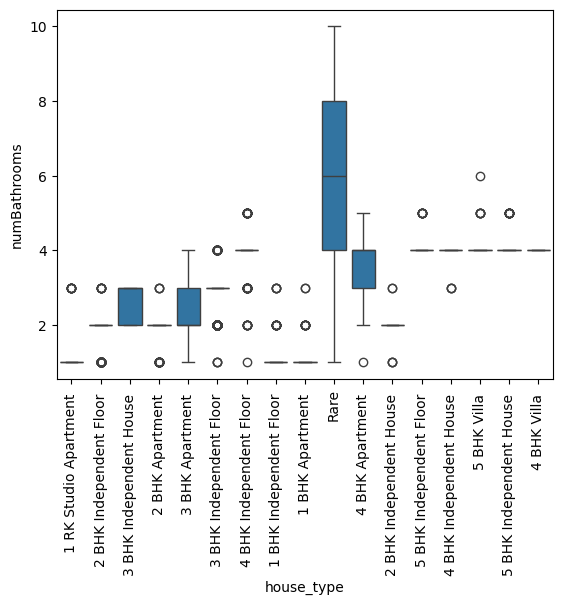

                     sum_sq      df           F  PR(>F)
C(house_type)  1.902430e+15    16.0  234.478358     0.0
Residual       2.201282e+15  4341.0         NaN     NaN


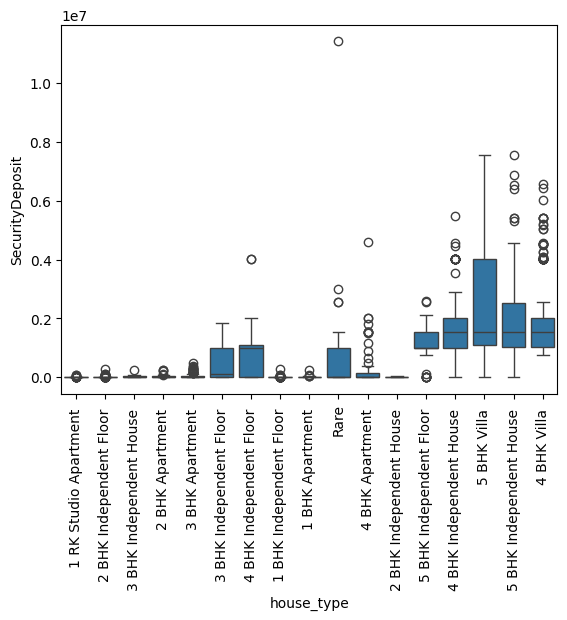

                   sum_sq      df          F  PR(>F)
C(location)  1.188977e+10   112.0  52.276875     0.0
Residual     8.620323e+09  4245.0        NaN     NaN


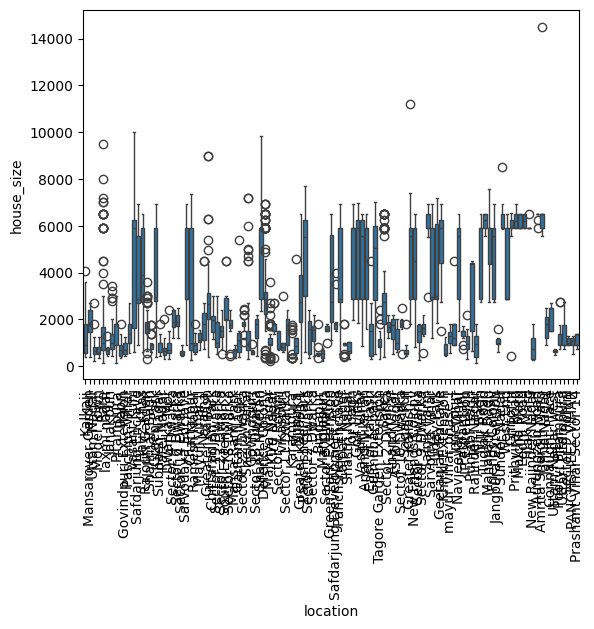

                  sum_sq      df          F  PR(>F)
C(location)  2547.037135   112.0  37.127197     0.0
Residual     2600.176266  4245.0        NaN     NaN


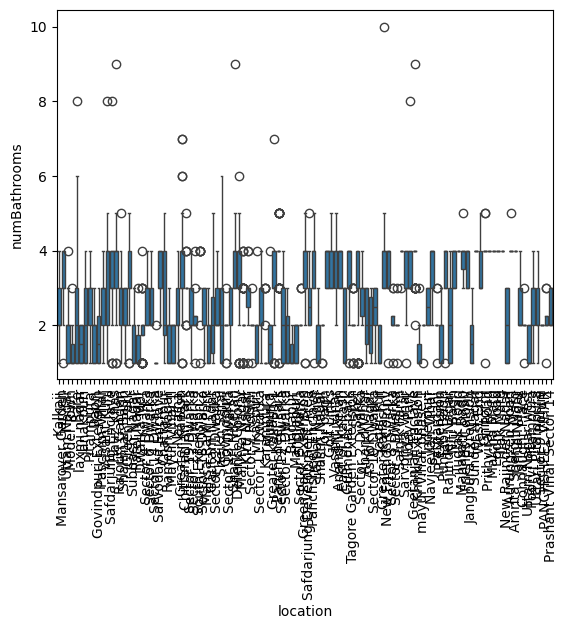

                   sum_sq      df          F  PR(>F)
C(location)  2.499169e+15   112.0  59.034244     0.0
Residual     1.604543e+15  4245.0        NaN     NaN


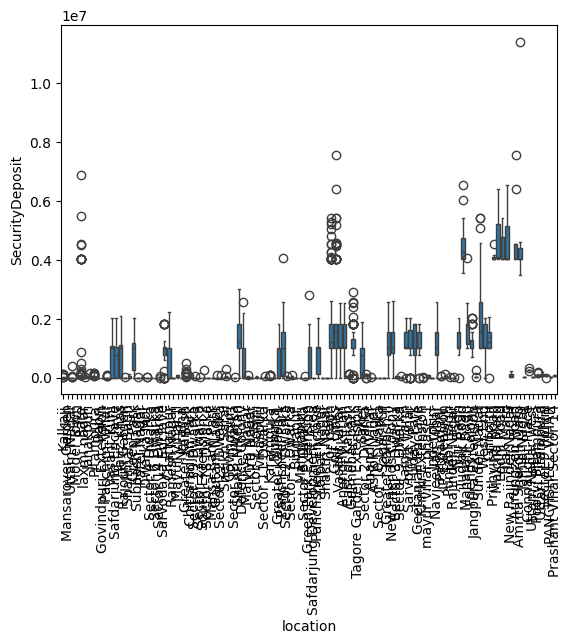

                           sum_sq      df          F  PR(>F)
C(verificationDate)  7.359565e+09    31.0  78.096893     0.0
Residual             1.315053e+10  4326.0        NaN     NaN


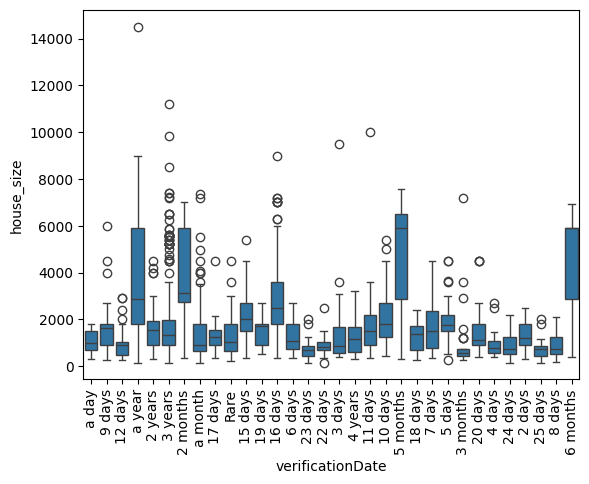

                          sum_sq      df          F         PR(>F)
C(verificationDate)  1309.933835    31.0  47.637695  2.285606e-248
Residual             3837.279566  4326.0        NaN            NaN


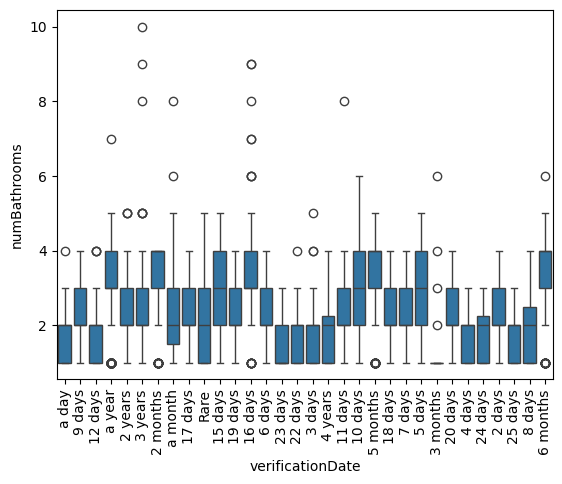

                           sum_sq      df          F  PR(>F)
C(verificationDate)  1.462305e+15    31.0  77.255146     0.0
Residual             2.641407e+15  4326.0        NaN     NaN


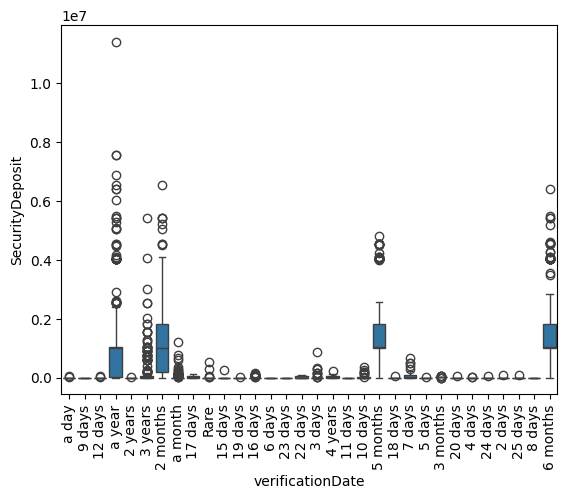

                 sum_sq      df            F  PR(>F)
C(Status)  9.820374e+09     2.0  2000.413933     0.0
Residual   1.068972e+10  4355.0          NaN     NaN


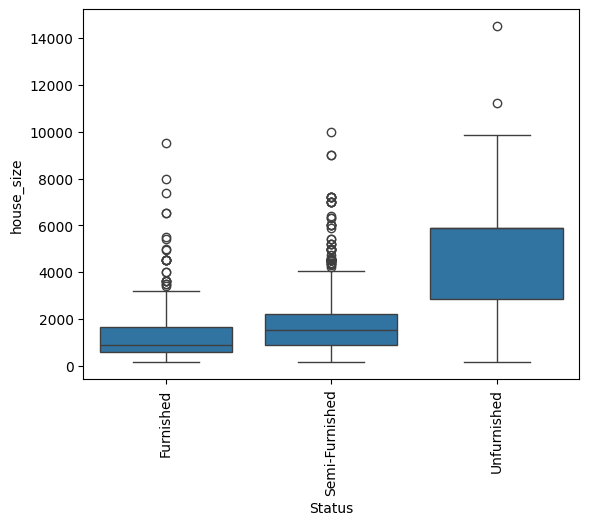

                sum_sq      df           F         PR(>F)
C(Status)  1388.796971     2.0  804.622229  4.214596e-298
Residual   3758.416430  4355.0         NaN            NaN


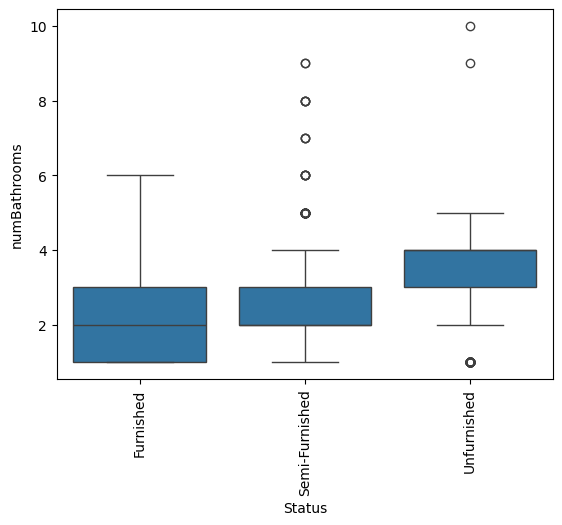

                 sum_sq      df            F  PR(>F)
C(Status)  1.915856e+15     2.0  1906.787088     0.0
Residual   2.187856e+15  4355.0          NaN     NaN


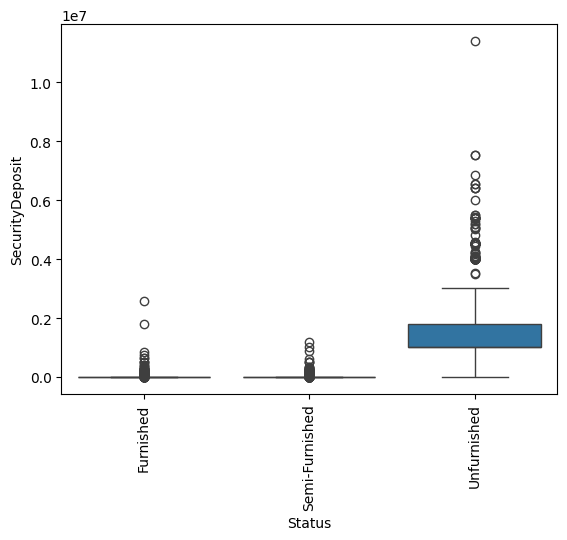

## Detect Outlier and treatment

Seem we have many outlier, we can seperate into 2 case.  
* Keep all outlier and apply RobustScaler
* Remove all outlier and apply MinMaxScaler

### Case 1: Keep all outlier

### Case 2: Remove all oulier

variable house_size have 0.023% upper outlier
variable house_size have 0.0% lower outlier
variable numBathrooms have 0.184% upper outlier
variable numBathrooms have 0.0% lower outlier
variable SecurityDeposit have 3.534% upper outlier
variable SecurityDeposit have 0.0% lower outlier


160

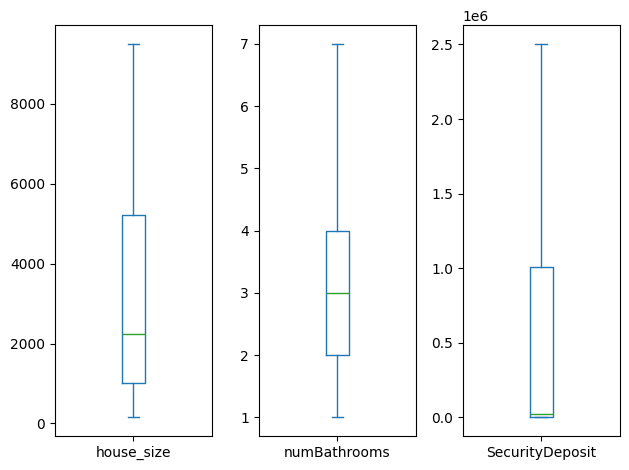

Finally, we have 2 case
* `_df_house_in_keep` which keep all outlier 
* `_df_house_in_remove_outlier` which remove outlier all numeric variables

## Data Standardization

,house_type,location,verificationDate,Status,house_size,numBathrooms,SecurityDeposit,price
0,1 RK Studio Apartment,Kalkaji,a day,Furnished,400,1.0,0,22000
1,1 RK Studio Apartment,Mansarover Garden,9 days,Furnished,400,1.0,0,20000
2,2 BHK Independent Floor,Uttam Nagar,12 days,Semi-Furnished,500,1.0,0,8500
3,3 BHK Independent House,Model Town,a year,Furnished,1020,3.0,0,48000
4,2 BHK Apartment,Rare,a year,Unfurnished,810,2.0,0,20000


,house_type,location,verificationDate,Status,house_size,numBathrooms,SecurityDeposit,price
0,1 RK Studio Apartment,Kalkaji,a day,Furnished,400,1.0,0,22000
1,1 RK Studio Apartment,Mansarover Garden,9 days,Furnished,400,1.0,0,20000
2,2 BHK Independent Floor,Uttam Nagar,12 days,Semi-Furnished,500,1.0,0,8500
3,3 BHK Independent House,Model Town,a year,Furnished,1020,3.0,0,48000
4,2 BHK Apartment,Rare,a year,Unfurnished,810,2.0,0,20000


### Scaler for non outlier data

In [74]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

,house_type,location,verificationDate,Status,house_size,numBathrooms,SecurityDeposit,price,S_house_size,S_numBathrooms,S_SecurityDeposit
0,1 RK Studio Apartment,Kalkaji,a day,Furnished,400,1.0,0,22000,0.026738,0.000000,0.0
1,1 RK Studio Apartment,Mansarover Garden,9 days,Furnished,400,1.0,0,20000,0.026738,0.000000,0.0
2,2 BHK Independent Floor,Uttam Nagar,12 days,Semi-Furnished,500,1.0,0,8500,0.037433,0.000000,0.0
3,3 BHK Independent House,Model Town,a year,Furnished,1020,3.0,0,48000,0.093048,0.333333,0.0
4,2 BHK Apartment,Rare,a year,Unfurnished,810,2.0,0,20000,0.070588,0.166667,0.0


### Scaler for outlier data

,house_type,location,verificationDate,Status,house_size,numBathrooms,SecurityDeposit,price,S_house_size,S_numBathrooms,S_SecurityDeposit
0,1 RK Studio Apartment,Kalkaji,a day,Furnished,400,1.0,0,22000,-0.433795,-1.0,-0.035573
1,1 RK Studio Apartment,Mansarover Garden,9 days,Furnished,400,1.0,0,20000,-0.433795,-1.0,-0.035573
2,2 BHK Independent Floor,Uttam Nagar,12 days,Semi-Furnished,500,1.0,0,8500,-0.413138,-1.0,-0.035573
3,3 BHK Independent House,Model Town,a year,Furnished,1020,3.0,0,48000,-0.305722,0.0,-0.035573
4,2 BHK Apartment,Rare,a year,Unfurnished,810,2.0,0,20000,-0.349101,-0.5,-0.035573


Finally, we have 2 options:
* `_df_house_in_remove_outlier` for non outlier data which apply MinMaxScaler
* `_df_house_in_keep` for outlier data which apply RobustScaler

## Feature Engineering

### Encoder for non outlier data

,house_type,location,verificationDate,Status
0,1 RK Studio Apartment,Kalkaji,a day,Furnished
1,1 RK Studio Apartment,Mansarover Garden,9 days,Furnished
2,2 BHK Independent Floor,Uttam Nagar,12 days,Semi-Furnished
3,3 BHK Independent House,Model Town,a year,Furnished
4,2 BHK Apartment,Rare,a year,Unfurnished


,house_type,verificationDate,house_size,numBathrooms,SecurityDeposit,price,S_house_size,S_numBathrooms,S_SecurityDeposit,E_Anand Vihar,...,E_Uttam Nagar west,E_Uttari Pitampura,E_Vasant Kunj,E_Vasant Vihar,E_West End,E_laxmi nagar,E_mayur vihar phase 1,E_vikaspuri,E_Semi-Furnished,E_Unfurnished
0,1 RK Studio Apartment,a day,400,1.0,0,22000,0.026738,0.000000,0.0,0,...,0,0,0,0,0,0,0,0,0,0
1,1 RK Studio Apartment,9 days,400,1.0,0,20000,0.026738,0.000000,0.0,0,...,0,0,0,0,0,0,0,0,0,0
2,2 BHK Independent Floor,12 days,500,1.0,0,8500,0.037433,0.000000,0.0,0,...,0,0,0,0,0,0,0,0,1,0
3,3 BHK Independent House,a year,1020,3.0,0,48000,0.093048,0.333333,0.0,0,...,0,0,0,0,0,0,0,0,0,0
4,2 BHK Apartment,a year,810,2.0,0,20000,0.070588,0.166667,0.0,0,...,0,0,0,0,0,0,0,0,0,1


In [90]:
from sklearn.preprocessing import LabelEncoder

,house_type,verificationDate,house_size,numBathrooms,SecurityDeposit,price,S_house_size,S_numBathrooms,S_SecurityDeposit,E_Anand Vihar,...,E_Uttam Nagar west,E_Uttari Pitampura,E_Vasant Kunj,E_Vasant Vihar,E_West End,E_laxmi nagar,E_mayur vihar phase 1,E_vikaspuri,E_Semi-Furnished,E_Unfurnished
0,2,29,400,1.0,0,22000,0.026738,0.000000,0.0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,27,400,1.0,0,20000,0.026738,0.000000,0.0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,2,500,1.0,0,8500,0.037433,0.000000,0.0,0,...,0,0,0,0,0,0,0,0,1,0
3,8,31,1020,3.0,0,48000,0.093048,0.333333,0.0,0,...,0,0,0,0,0,0,0,0,0,0
4,3,31,810,2.0,0,20000,0.070588,0.166667,0.0,0,...,0,0,0,0,0,0,0,0,0,1


### Encoder for outlier data

,house_type,verificationDate,house_size,numBathrooms,SecurityDeposit,price,S_house_size,S_numBathrooms,S_SecurityDeposit,E_Anand Niketan,...,E_Uttam Nagar west,E_Uttari Pitampura,E_Vasant Kunj,E_Vasant Vihar,E_West End,E_laxmi nagar,E_mayur vihar phase 1,E_vikaspuri,E_Semi-Furnished,E_Unfurnished
0,1 RK Studio Apartment,a day,400,1.0,0,22000,-0.433795,-1.0,-0.035573,0,...,0,0,0,0,0,0,0,0,0,0
1,1 RK Studio Apartment,9 days,400,1.0,0,20000,-0.433795,-1.0,-0.035573,0,...,0,0,0,0,0,0,0,0,0,0
2,2 BHK Independent Floor,12 days,500,1.0,0,8500,-0.413138,-1.0,-0.035573,0,...,0,0,0,0,0,0,0,0,1,0
3,3 BHK Independent House,a year,1020,3.0,0,48000,-0.305722,0.0,-0.035573,0,...,0,0,0,0,0,0,0,0,0,0
4,2 BHK Apartment,a year,810,2.0,0,20000,-0.349101,-0.5,-0.035573,0,...,0,0,0,0,0,0,0,0,0,1


,house_type,verificationDate,house_size,numBathrooms,SecurityDeposit,price,S_house_size,S_numBathrooms,S_SecurityDeposit,E_Anand Niketan,...,E_Uttam Nagar west,E_Uttari Pitampura,E_Vasant Kunj,E_Vasant Vihar,E_West End,E_laxmi nagar,E_mayur vihar phase 1,E_vikaspuri,E_Semi-Furnished,E_Unfurnished
0,2,29,400,1.0,0,22000,-0.433795,-1.0,-0.035573,0,...,0,0,0,0,0,0,0,0,0,0
1,2,27,400,1.0,0,20000,-0.433795,-1.0,-0.035573,0,...,0,0,0,0,0,0,0,0,0,0
2,4,2,500,1.0,0,8500,-0.413138,-1.0,-0.035573,0,...,0,0,0,0,0,0,0,0,1,0
3,8,31,1020,3.0,0,48000,-0.305722,0.0,-0.035573,0,...,0,0,0,0,0,0,0,0,0,0
4,3,31,810,2.0,0,20000,-0.349101,-0.5,-0.035573,0,...,0,0,0,0,0,0,0,0,0,1


Now, we finished preprocessing data and move to modelling 

## Build model

In [98]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Case 1: Modelling for non outlier data with scaler

Index(['house_type', 'verificationDate', 'house_size', 'numBathrooms',
       'SecurityDeposit', 'price', 'S_house_size', 'S_numBathrooms',
       'S_SecurityDeposit', 'E_Anand Vihar',
       ...
       'E_Uttam Nagar west', 'E_Uttari Pitampura', 'E_Vasant Kunj',
       'E_Vasant Vihar', 'E_West End', 'E_laxmi nagar',
       'E_mayur vihar phase 1', 'E_vikaspuri', 'E_Semi-Furnished',
       'E_Unfurnished'],
      dtype='object', length=116)

LinearRegression()

In [105]:
from sklearn.metrics import r2_score, mean_squared_error

score of training without outlier 0.848
score of test without outlier 0.861
rmse of training without outlier 67123.295
rmse of test without outlier 63459.072


Charges: Min - 3000, Max - 2000000, Range - 1997000


### Case 1.1: Modelling for outlier data with scaler

Index(['house_type', 'verificationDate', 'house_size', 'numBathrooms',
       'SecurityDeposit', 'price', 'S_house_size', 'S_numBathrooms',
       'S_SecurityDeposit', 'E_Anand Niketan',
       ...
       'E_Uttam Nagar west', 'E_Uttari Pitampura', 'E_Vasant Kunj',
       'E_Vasant Vihar', 'E_West End', 'E_laxmi nagar',
       'E_mayur vihar phase 1', 'E_vikaspuri', 'E_Semi-Furnished',
       'E_Unfurnished'],
      dtype='object', length=123)

LinearRegression()

score of training keep outlier 0.89
score of test keep outlier 0.902
rmse of training keep outlier 91035.999
rmse of test keep outlier 81274.728


Sale: Min - 3000, Max - 3010101, Range - 3007101


### Case 2: Modelling for non outlier data without scaler

Index(['house_type', 'verificationDate', 'house_size', 'numBathrooms',
       'SecurityDeposit', 'price', 'S_house_size', 'S_numBathrooms',
       'S_SecurityDeposit', 'E_Anand Vihar',
       ...
       'E_Uttam Nagar west', 'E_Uttari Pitampura', 'E_Vasant Kunj',
       'E_Vasant Vihar', 'E_West End', 'E_laxmi nagar',
       'E_mayur vihar phase 1', 'E_vikaspuri', 'E_Semi-Furnished',
       'E_Unfurnished'],
      dtype='object', length=116)

LinearRegression()

score of training without outlier 0.848
score of test without outlier 0.861
rmse of training without outlier 67123.295
rmse of test without outlier 63459.072


Charges: Min - 3000, Max - 2000000, Range - 1997000


### 2.1 Modelling for outlier data without scaler

LinearRegression()

score of training keep outlier 0.89
score of test keep outlier 0.902
rmse of training keep outlier 91035.999
rmse of test keep outlier 81274.728


Sale: Min - 3000, Max - 3010101, Range - 3007101


## Conclusion

## Summary

|Remove outlier|Apply Scaler|R2 train|rmse train|R2 test|rmse test|
|---|---|---|---|---|---|
|Yes|Yes|0.848|67123.295|0.861|63459.072|
|No|Yes|0.89|91035.999|0.902|81274.728|
|Yes|No|0.848|67123.295|0.861|63459.072|
|No|No|0.89|91035.999|0.902|81274.728|

Conclusion: 
* Apply scaler not impact to result of model
* Remove Outlier make model have lower rmse